# Cluster HFpEF

In [1]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import seaborn as sn

from IPython.display import display

from preproc import get_hfpef_200, convert2np

In [2]:
no_clusters = 8
lbl_colname= ['Death', 'CV death', 'Major cardiac events']

## Get Data

In [3]:
data_df = get_hfpef_200()

In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   200 non-null    int64  
 1   Sex                   200 non-null    int64  
 2   Cr                    200 non-null    float64
 3   GFR                   200 non-null    float64
 4   CKD stage             200 non-null    int64  
 5   smoke                 200 non-null    float64
 6   BMI                   200 non-null    float64
 7   BSA                   200 non-null    float64
 8   DM                    200 non-null    int64  
 9   Insulin               200 non-null    int64  
 10  AF                    200 non-null    int64  
 11  SBP                   200 non-null    int64  
 12  DBP                   200 non-null    int64  
 13  MAP                   200 non-null    float64
 14  PP                    200 non-null    int64  
 15  1/2SBP                2

In [6]:
data_df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,...,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,72.045000,1.680000,1.711100,52.293250,2.810000,0.105000,26.738830,1.632980,0.560000,0.215000,...,0.741571,17.300650,1.890100,0.648305,115.640950,2.640000,17.428481,3.211636,16.797793,61.434500
std,11.404529,0.467647,1.534721,25.188572,1.043718,0.307323,6.636857,0.228277,0.497633,0.411853,...,0.606755,8.602117,1.443655,0.388423,52.778994,1.896943,52.106319,3.988946,18.158083,8.420635
min,31.000000,1.000000,0.550000,2.000000,1.000000,0.000000,15.400000,1.120000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000,0.000000,0.000000,0.000000
25%,65.000000,1.000000,0.887500,34.750000,2.000000,0.000000,22.200000,1.485000,0.000000,0.000000,...,0.500000,11.600000,0.000000,0.400000,86.725000,1.000000,0.000000,0.000000,3.700000,56.000000
50%,74.000000,2.000000,1.140000,54.000000,3.000000,0.000000,26.300000,1.600000,1.000000,0.000000,...,0.700000,16.300000,2.460000,0.555000,113.150000,2.500000,32.600000,2.479869,4.500000,61.000000
75%,80.000000,2.000000,1.792500,70.250000,3.000000,0.000000,29.925000,1.800000,1.000000,0.000000,...,1.000000,22.100000,3.002500,0.865000,141.305000,4.000000,48.425000,5.111374,37.692250,66.000000
max,97.000000,2.000000,10.000000,108.000000,5.000000,1.000000,55.900000,2.300000,1.000000,1.000000,...,4.100000,42.200000,4.550000,2.300000,356.600000,7.000000,140.800000,23.665480,59.919000,82.900000


## 1. All Features

In [7]:
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.mixture import GaussianMixture

from sklearn.pipeline import make_pipeline

from utils import get_score, score_columns, plot_clustering_score, plot_contingency_matrix, plot_bic_aic

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('ggplot')

In [8]:
X, y, feature_list = convert2np(data_df, lbl_colname)

In [9]:
def get_km_pred(k, X):
    km = KMeans(n_clusters=k, random_state=0)
    return km.fit_predict(X)

def get_sc_pred(k, X):
    sc = SpectralClustering(n_clusters=k, eigen_solver='arpack', affinity="nearest_neighbors", random_state=0)
    return sc.fit_predict(X)

def get_gm_pred(k, X):
    gm = GaussianMixture(n_components=k, random_state=0, init_params='kmeans').fit(X)
    return gm.predict(X)

In [10]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

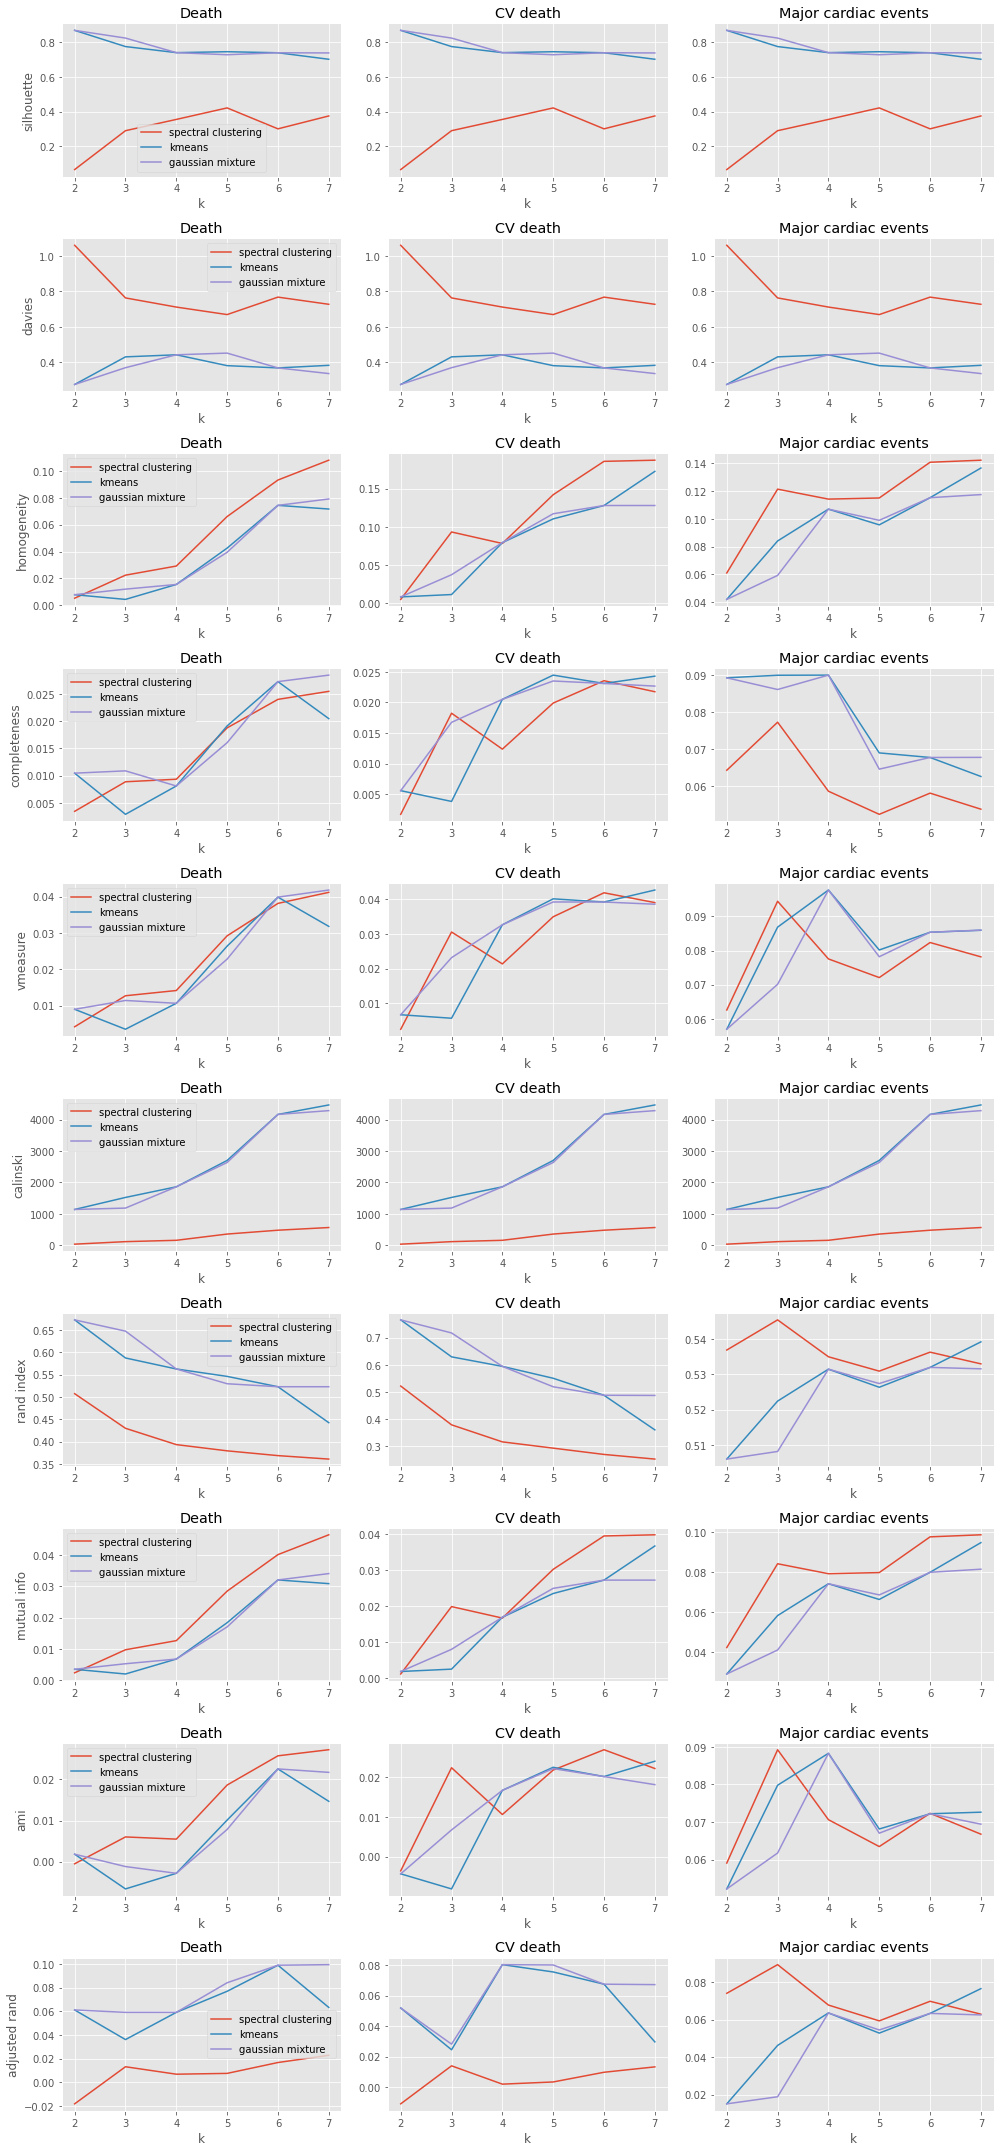

In [11]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

The meaning of the scores.
<!-- * `BIC` lower is better
* `AIC` lower is better -->
* `silhouette` higher is better
* `davies` lower is better
* `homogeneity` higher is better
* `completeness` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `v-measure` higher is better
* `calinski` higher is better
* `rand index` higher is better
* `mutual info` higher is better

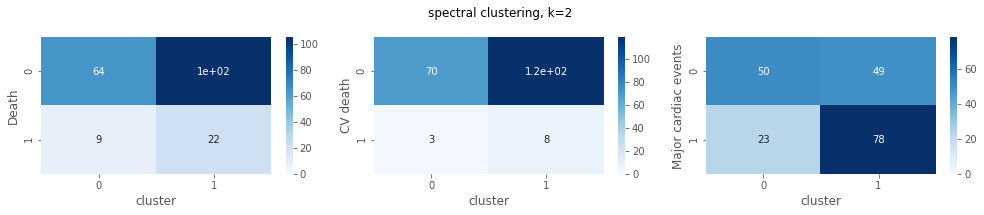

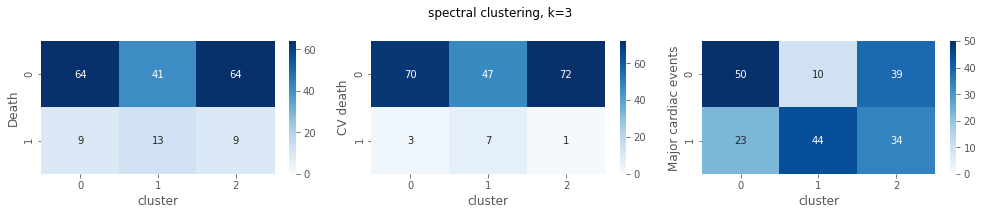

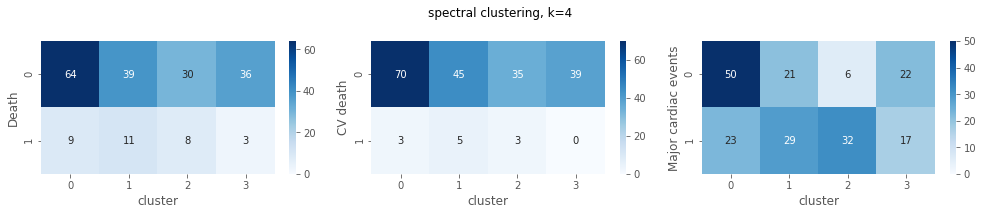

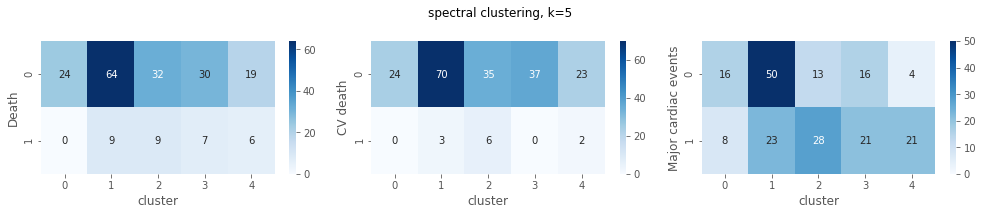

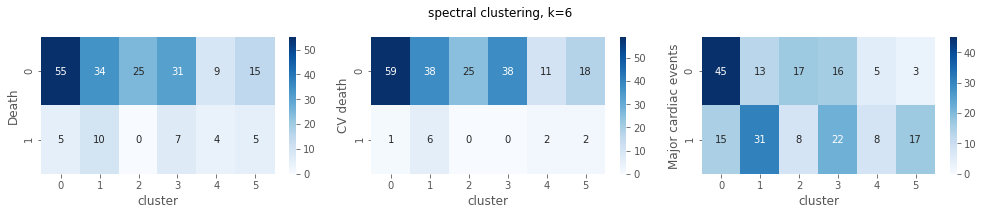

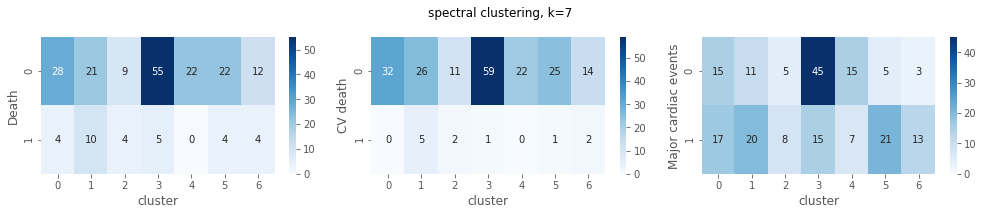

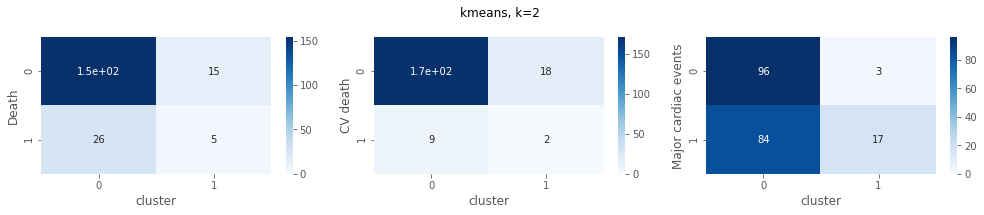

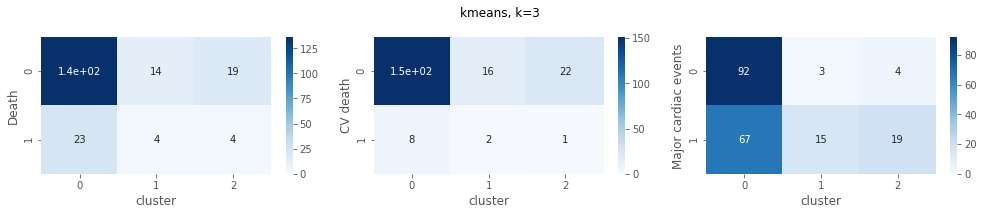

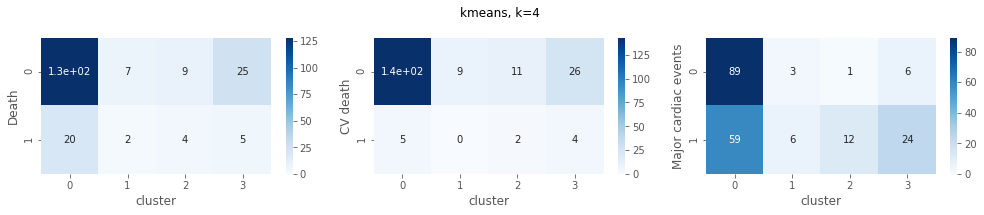

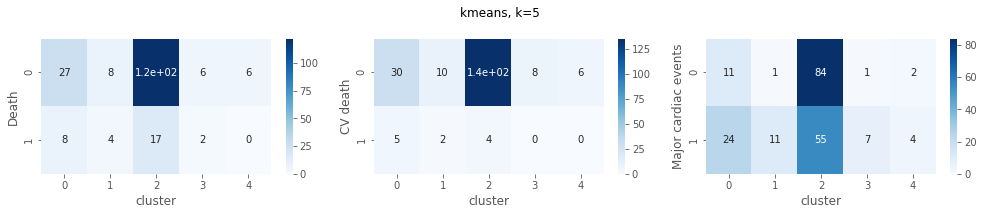

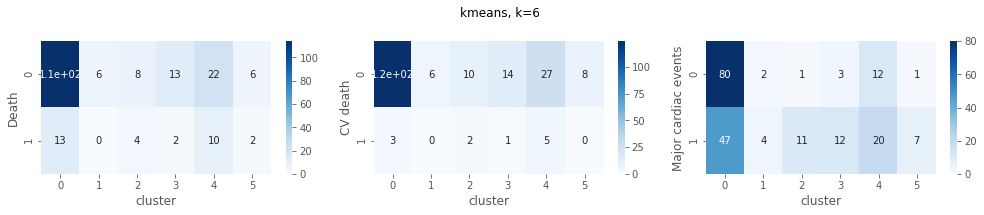

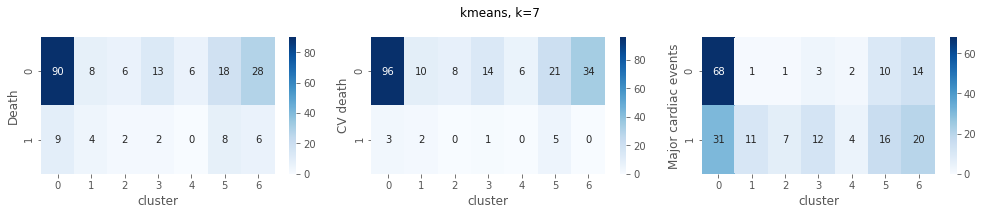

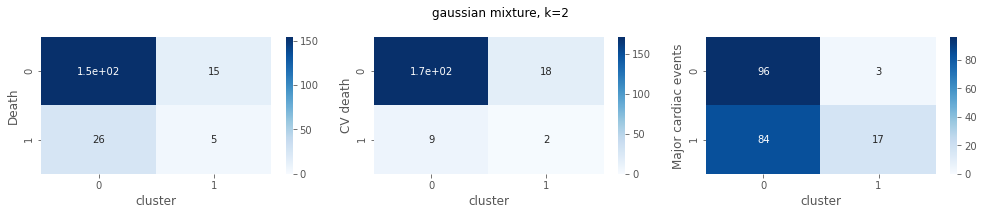

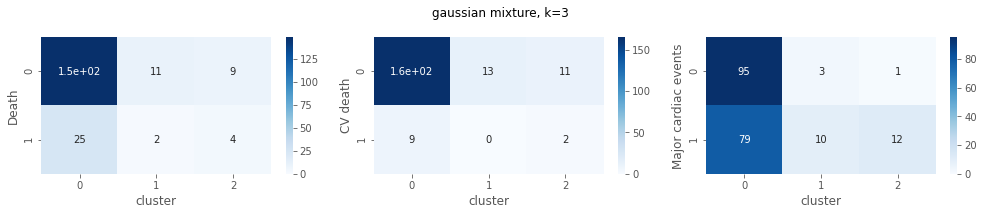

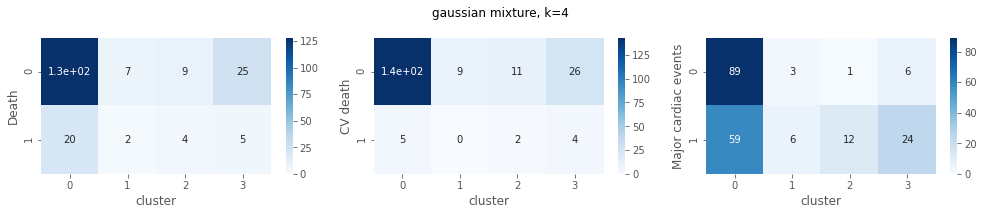

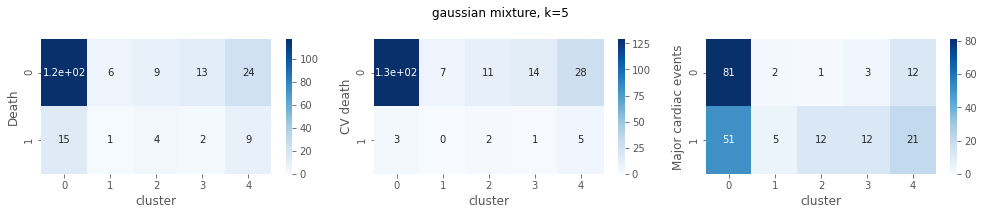

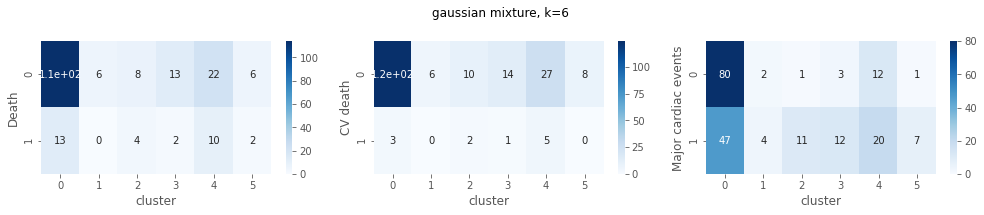

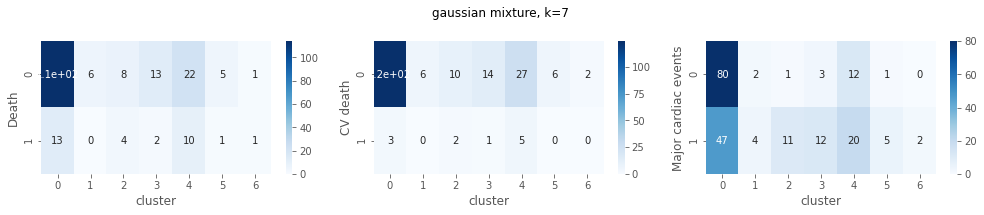

In [12]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [13]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.064548,1.060231,0.005263,0.003459,0.004175,36.019865,0.507337,0.002270,-0.000514,-0.018225,"[[64, 105], [9, 22]]","[73, 127]"
1,3,0.289461,0.762849,0.022406,0.008871,0.012710,116.087102,0.429950,0.009663,0.006014,0.013130,"[[64, 41, 64], [9, 13, 9]]","[73, 54, 73]"
2,4,0.354639,0.711149,0.029196,0.009336,0.014148,158.547706,0.393467,0.012592,0.005482,0.006833,"[[64, 39, 30, 36], [9, 11, 8, 3]]","[73, 50, 38, 39]"
3,5,0.421280,0.668681,0.066029,0.018744,0.029199,357.222960,0.379548,0.028477,0.018624,0.007511,"[[24, 64, 32, 30, 19], [0, 9, 9, 7, 6]]","[24, 73, 41, 37, 25]"
4,6,0.300172,0.767344,0.093215,0.023963,0.038125,479.676812,0.368844,0.040202,0.025733,0.016698,"[[55, 34, 25, 31, 9, 15], [5, 10, 0, 7, 4, 5]]","[60, 44, 25, 38, 13, 20]"
5,7,0.374689,0.726819,0.107974,0.025431,0.041166,565.052650,0.361106,0.046567,0.027214,0.022824,"[[28, 21, 9, 55, 22, 22, 12], [4, 10, 4, 5, 0,...","[32, 31, 13, 60, 22, 26, 16]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.869991,0.273740,0.007875,0.010448,0.008981,1139.641251,0.672412,0.003396,0.001817,0.061134,"[[154, 15], [26, 5]]","[180, 20]"
1,3,0.776230,0.429755,0.004372,0.002910,0.003494,1522.279358,0.587236,0.001885,-0.006622,0.036091,"[[136, 14, 19], [23, 4, 4]]","[159, 18, 23]"
2,4,0.741085,0.441455,0.015486,0.008099,0.010636,1860.011389,0.562613,0.006679,-0.002828,0.059097,"[[128, 7, 9, 25], [20, 2, 4, 5]]","[148, 9, 13, 30]"
3,5,0.746447,0.380167,0.042540,0.019099,0.026362,2698.766503,0.546030,0.018347,0.010111,0.076906,"[[27, 8, 122, 6, 6], [8, 4, 17, 2, 0]]","[35, 12, 139, 8, 6]"
4,6,0.740412,0.367319,0.074365,0.027212,0.039844,4162.614464,0.522915,0.032072,0.022545,0.098953,"[[114, 6, 8, 13, 22, 6], [13, 0, 4, 2, 10, 2]]","[127, 6, 12, 15, 32, 8]"
5,7,0.702760,0.381909,0.071632,0.020438,0.031803,4463.923232,0.442513,0.030894,0.014672,0.063275,"[[90, 8, 6, 13, 6, 18, 28], [9, 4, 2, 2, 0, 8,...","[99, 12, 8, 15, 6, 26, 34]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.064548,1.060231,0.060916,0.064337,0.062580,36.019865,0.536884,0.042221,0.059064,0.074080,"[[50, 49], [23, 78]]","[73, 127]"
1,3,0.289461,0.762849,0.121412,0.077255,0.094426,116.087102,0.545427,0.084150,0.089263,0.089384,"[[50, 10, 39], [23, 44, 34]]","[73, 54, 73]"
2,4,0.354639,0.711149,0.114221,0.058696,0.077544,158.547706,0.534975,0.079167,0.070622,0.067803,"[[50, 21, 6, 22], [23, 29, 32, 17]]","[73, 50, 38, 39]"
3,5,0.421280,0.668681,0.115044,0.052484,0.072083,357.222960,0.530905,0.079737,0.063460,0.059360,"[[16, 50, 13, 16, 4], [8, 23, 28, 21, 21]]","[24, 73, 41, 37, 25]"
4,6,0.300172,0.767344,0.140828,0.058179,0.082341,479.676812,0.536281,0.097607,0.072320,0.069818,"[[45, 13, 17, 16, 5, 3], [15, 31, 8, 22, 8, 17]]","[60, 44, 25, 38, 13, 20]"
5,7,0.374689,0.726819,0.142311,0.053866,0.078151,565.052650,0.532965,0.098635,0.066762,0.062931,"[[15, 11, 5, 45, 15, 5, 3], [17, 20, 8, 15, 7,...","[32, 31, 13, 60, 22, 26, 16]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.869991,0.273740,0.041834,0.089194,0.056955,1139.641251,0.505980,0.028995,0.052175,0.015055,"[[96, 3], [84, 17]]","[180, 20]"
1,3,0.776230,0.429755,0.084012,0.089883,0.086848,1522.279358,0.522412,0.058228,0.079802,0.046248,"[[92, 3, 4], [67, 15, 19]]","[159, 18, 23]"
2,4,0.741085,0.441455,0.106978,0.089917,0.097708,1860.011389,0.531457,0.074146,0.088307,0.063599,"[[89, 3, 1, 6], [59, 6, 12, 24]]","[148, 9, 13, 30]"
3,5,0.746447,0.380167,0.095637,0.069001,0.080165,2698.766503,0.526332,0.066286,0.068143,0.052825,"[[11, 1, 84, 1, 2], [24, 11, 55, 7, 4]]","[35, 12, 139, 8, 6]"
4,6,0.740412,0.367319,0.115247,0.067772,0.085352,4162.614464,0.531960,0.079877,0.072202,0.063345,"[[80, 2, 1, 3, 12, 1], [47, 4, 11, 12, 20, 7]]","[127, 6, 12, 15, 32, 8]"
5,7,0.702760,0.381909,0.136657,0.062661,0.085924,4463.923232,0.539196,0.094717,0.072619,0.076564,"[[68, 1, 1, 3, 2, 10, 14], [31, 11, 7, 12, 4, ...","[99, 12, 8, 15, 6, 26, 34]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.869991,0.273740,0.041834,0.089194,0.056955,1139.641251,0.505980,0.028995,0.052175,0.015055,"[[96, 3], [84, 17]]","[180, 20]"
1,3,0.825360,0.368600,0.059158,0.086049,0.070113,1183.762090,0.508141,0.041002,0.061742,0.018834,"[[95, 3, 1], [79, 10, 12]]","[174, 13, 13]"
2,4,0.741085,0.441455,0.106978,0.089917,0.097708,1860.011389,0.531457,0.074146,0.088307,0.063599,"[[89, 3, 1, 6], [59, 6, 12, 24]]","[148, 9, 13, 30]"
3,5,0.728890,0.450978,0.098924,0.064633,0.078184,2633.198500,0.527387,0.068564,0.067027,0.054506,"[[81, 2, 1, 3, 12], [51, 5, 12, 12, 21]]","[132, 7, 13, 15, 33]"
4,6,0.740412,0.367319,0.115247,0.067772,0.085352,4162.614464,0.531960,0.079877,0.072202,0.063345,"[[80, 2, 1, 3, 12, 1], [47, 4, 11, 12, 20, 7]]","[127, 6, 12, 15, 32, 8]"
5,7,0.739356,0.335412,0.117489,0.067797,0.085979,4283.191803,0.531558,0.081431,0.069431,0.062535,"[[80, 2, 1, 3, 12, 1, 0], [47, 4, 11, 12, 20, ...","[127, 6, 12, 15, 32, 6, 2]"


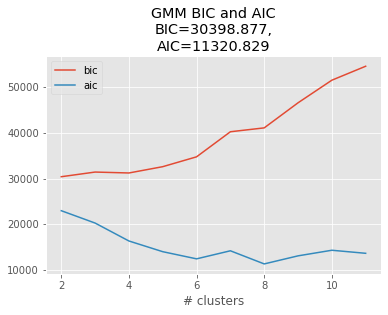

In [14]:
bics, aics = plot_bic_aic(X)

## 2. Selected Feature

In [15]:
X, y, feature_list = convert2np(data_df, lbl_colname, selected_feat=True)

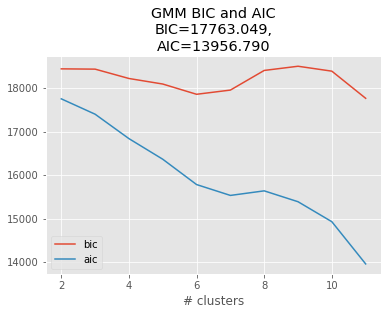

In [16]:
bics, aics = plot_bic_aic(X)

In [17]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-packages\sklearn\manifold\_spectral_embedding.py:245: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn("Graph is not fully connected, spectral embedding"
C:\Users\HP\miniconda3\lib\site-pack

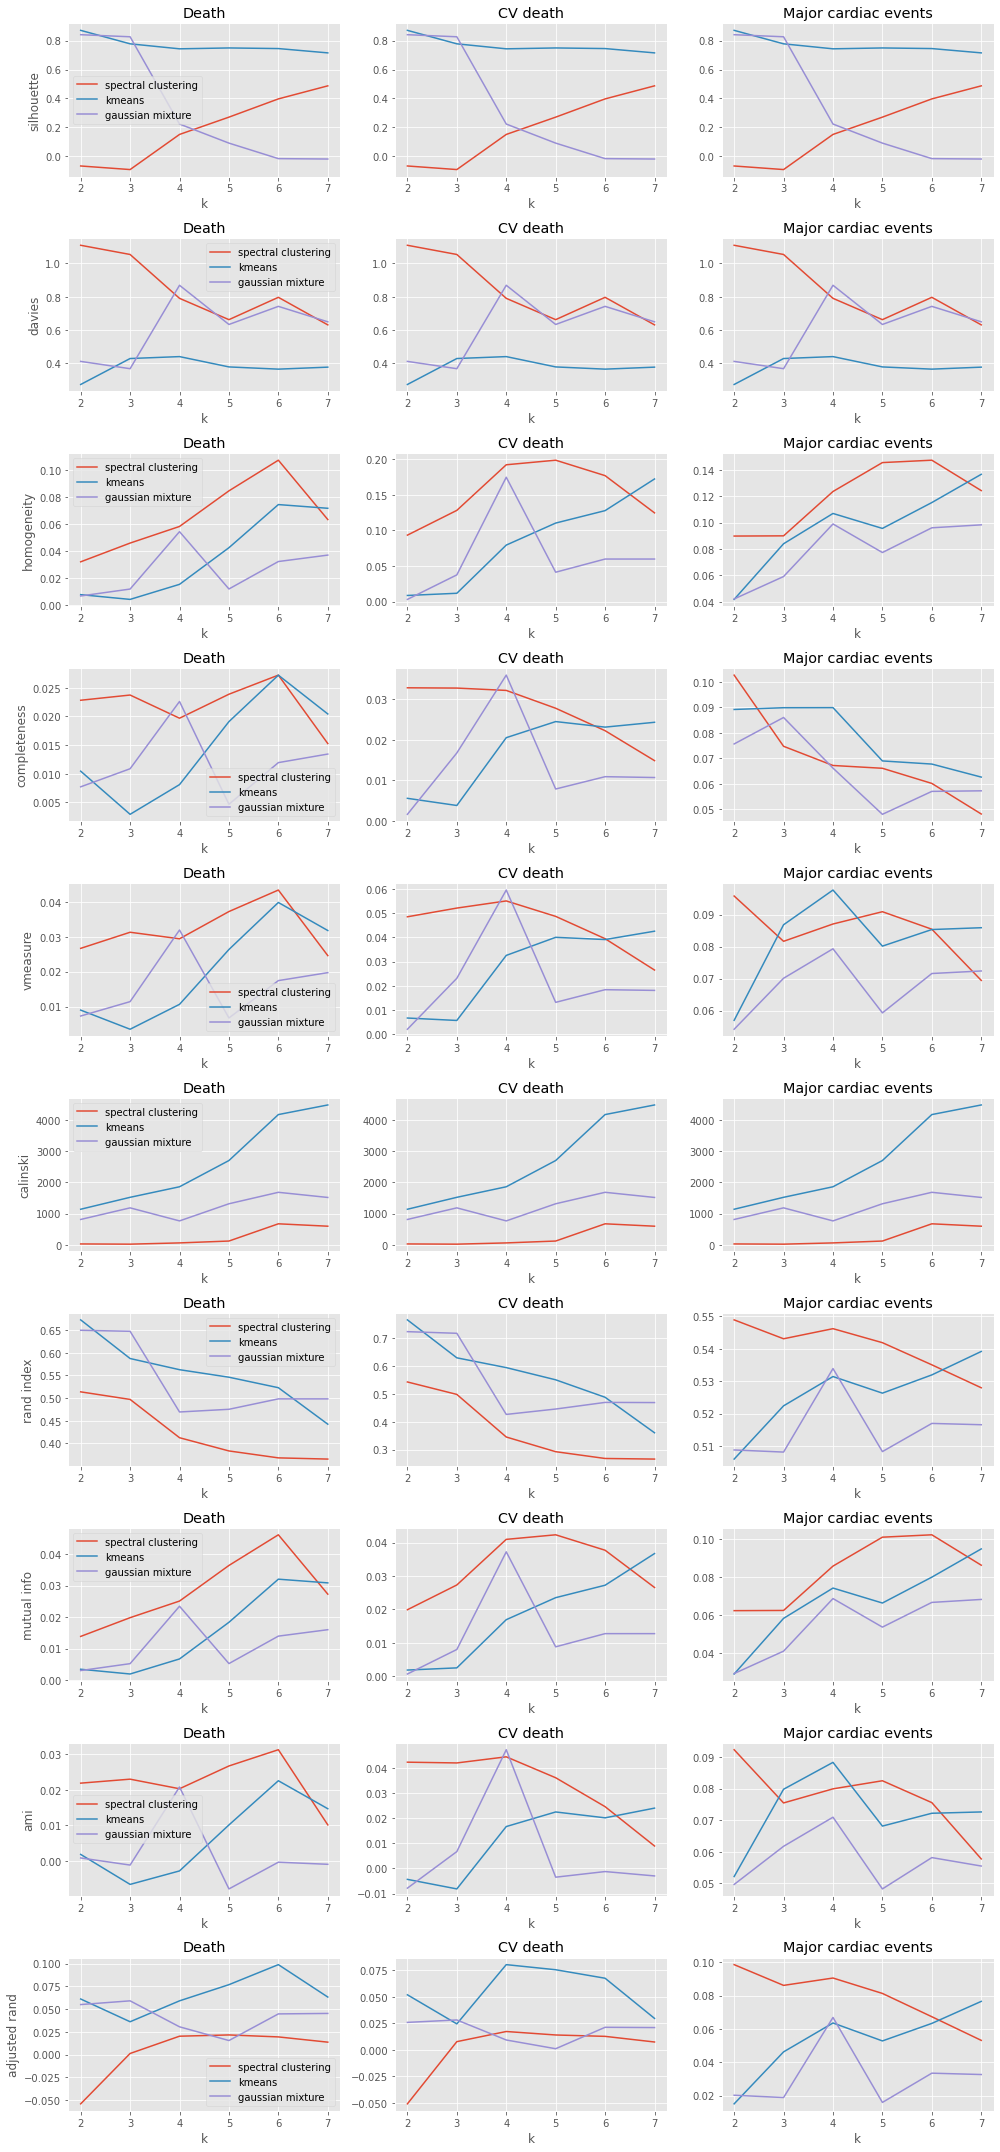

In [18]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

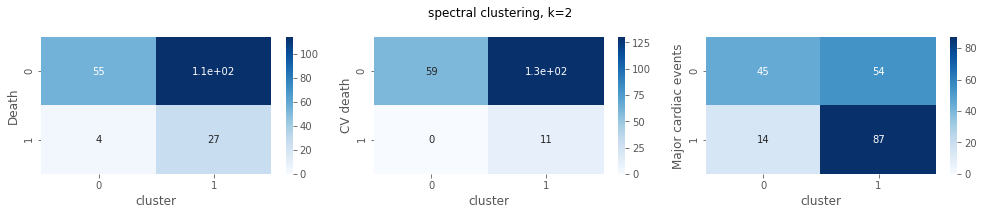

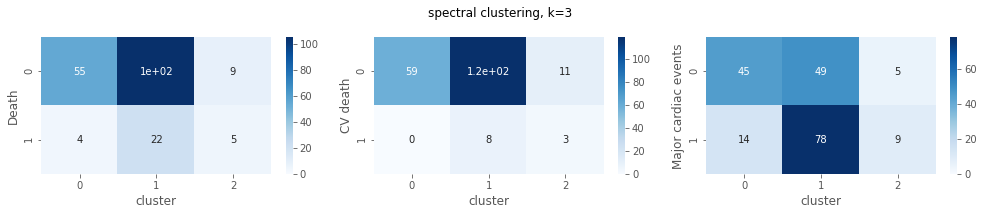

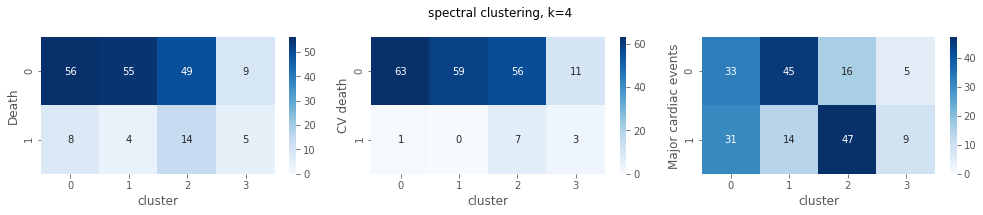

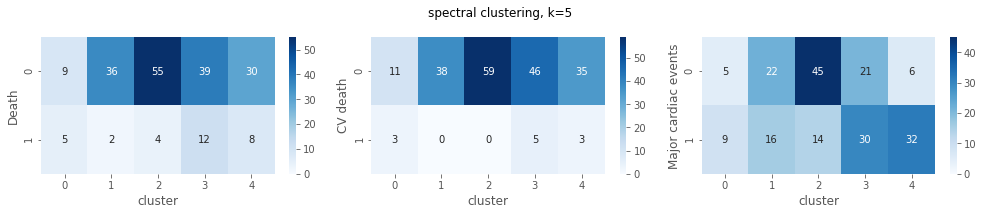

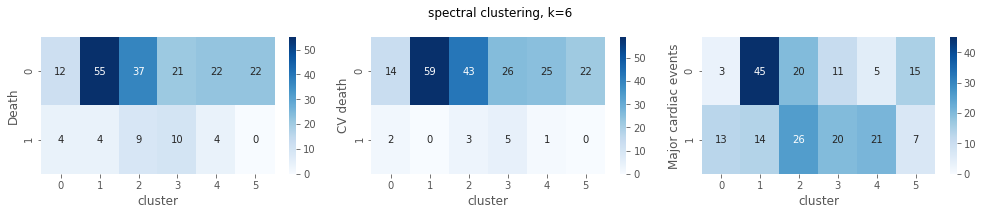

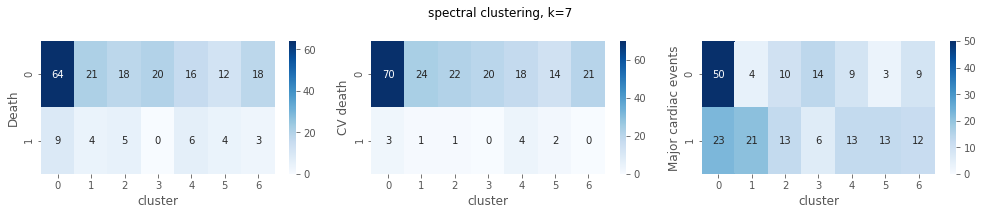

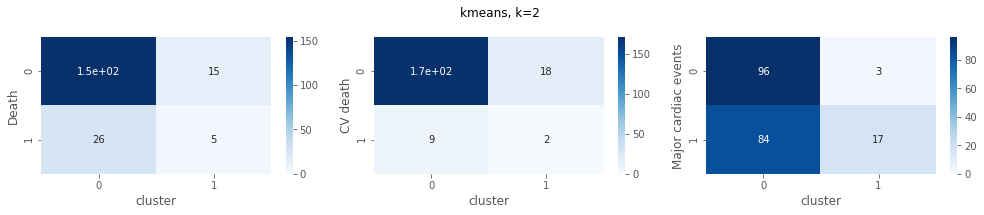

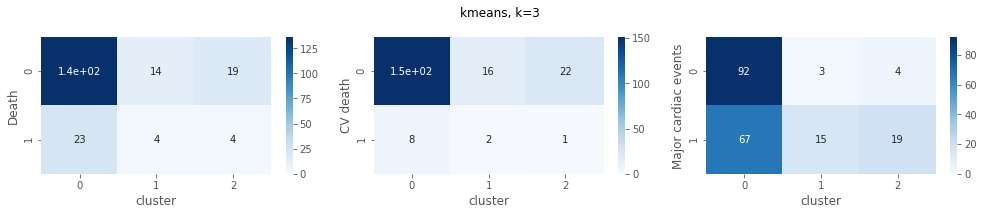

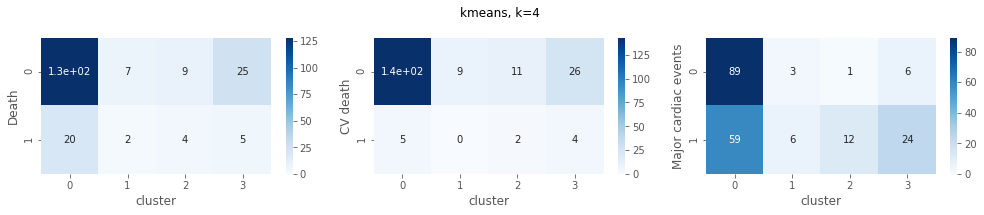

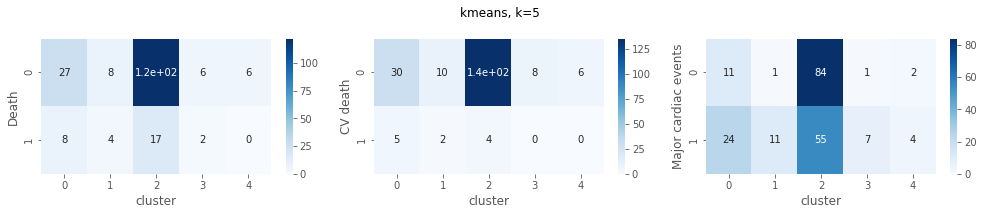

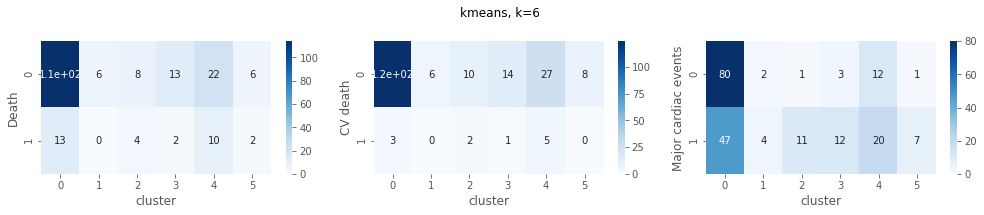

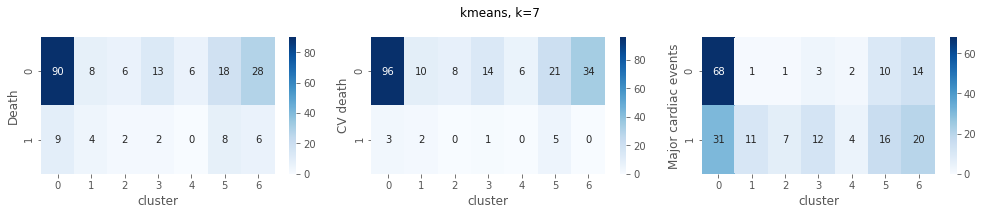

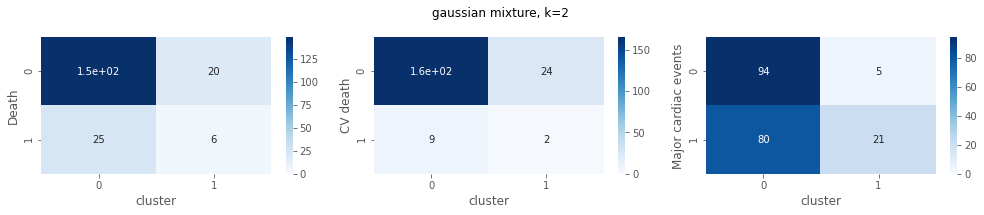

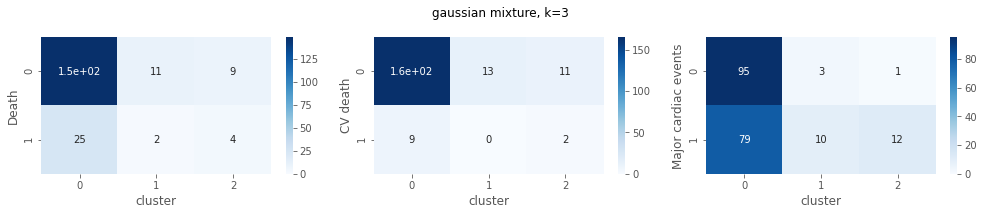

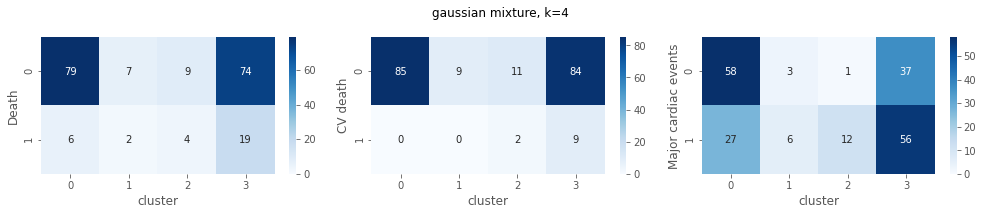

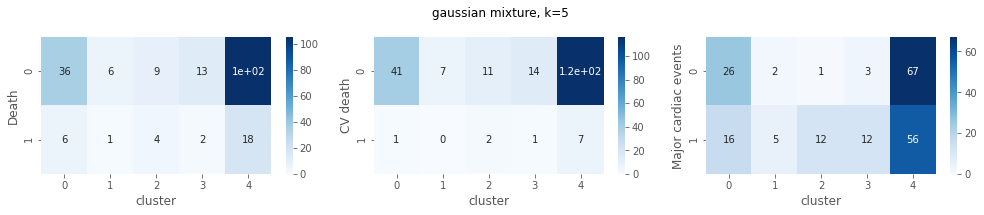

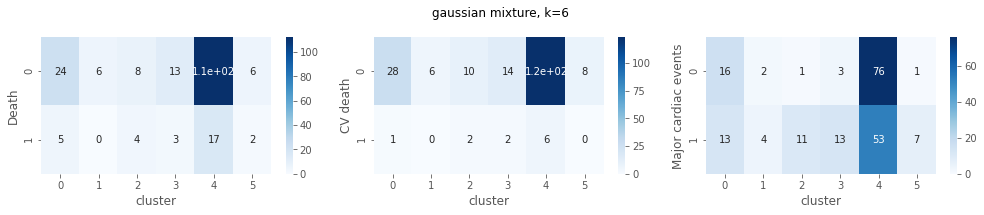

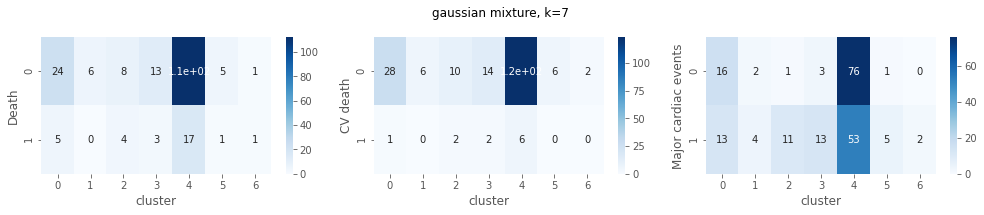

In [19]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [20]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,-0.066020,1.108937,0.032112,0.022832,0.026688,25.004023,0.513769,0.013849,0.021870,-0.054286,"[[55, 114], [4, 27]]","[59, 141]"
1,3,-0.090728,1.053764,0.045946,0.023742,0.031306,17.921503,0.497085,0.019816,0.022990,0.001158,"[[55, 105, 9], [4, 22, 5]]","[59, 127, 14]"
2,4,0.151745,0.790544,0.058215,0.019695,0.029433,58.196275,0.412663,0.025107,0.020292,0.020172,"[[56, 55, 49, 9], [8, 4, 14, 5]]","[64, 59, 63, 14]"
3,5,0.271189,0.662657,0.084500,0.023885,0.037243,118.223010,0.383518,0.036444,0.026703,0.021569,"[[9, 36, 55, 39, 30], [5, 2, 4, 12, 8]]","[14, 38, 59, 51, 38]"
4,6,0.397111,0.796689,0.107118,0.027220,0.043410,672.024429,0.368241,0.046199,0.031275,0.019393,"[[12, 55, 37, 21, 22, 22], [4, 4, 9, 10, 4, 0]]","[16, 59, 46, 31, 26, 22]"
5,7,0.487216,0.631391,0.063322,0.015272,0.024608,595.032046,0.365578,0.027310,0.010129,0.013620,"[[64, 21, 18, 20, 16, 12, 18], [9, 4, 5, 0, 6,...","[73, 25, 23, 20, 22, 16, 21]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870346,0.273665,0.007875,0.010448,0.008981,1139.987800,0.672412,0.003396,0.001817,0.061134,"[[154, 15], [26, 5]]","[180, 20]"
1,3,0.777363,0.429433,0.004372,0.002910,0.003494,1523.395374,0.587236,0.001885,-0.006622,0.036091,"[[136, 14, 19], [23, 4, 4]]","[159, 18, 23]"
2,4,0.742875,0.440937,0.015486,0.008099,0.010636,1862.408075,0.562613,0.006679,-0.002828,0.059097,"[[128, 7, 9, 25], [20, 2, 4, 5]]","[148, 9, 13, 30]"
3,5,0.748944,0.379012,0.042540,0.019099,0.026362,2705.475022,0.546030,0.018347,0.010111,0.076906,"[[27, 8, 122, 6, 6], [8, 4, 17, 2, 0]]","[35, 12, 139, 8, 6]"
4,6,0.744636,0.365698,0.074365,0.027212,0.039844,4182.526060,0.522915,0.032072,0.022545,0.098953,"[[114, 6, 8, 13, 22, 6], [13, 0, 4, 2, 10, 2]]","[127, 6, 12, 15, 32, 8]"
5,7,0.714862,0.377666,0.071632,0.020438,0.031803,4491.319200,0.442513,0.030894,0.014672,0.063275,"[[90, 8, 6, 13, 6, 18, 28], [9, 4, 2, 2, 0, 8,...","[99, 12, 8, 15, 6, 26, 34]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,-0.066020,1.108937,0.089853,0.102671,0.095835,25.004023,0.548945,0.062277,0.092309,0.098617,"[[45, 54], [14, 87]]","[59, 141]"
1,3,-0.090728,1.053764,0.090012,0.074747,0.081672,17.921503,0.543116,0.062387,0.075470,0.086165,"[[45, 49, 5], [14, 78, 9]]","[59, 127, 14]"
2,4,0.151745,0.790544,0.123630,0.067217,0.087086,58.196275,0.546231,0.085687,0.079928,0.090581,"[[33, 45, 16, 5], [31, 14, 47, 9]]","[64, 59, 63, 14]"
3,5,0.271189,0.662657,0.145553,0.066117,0.090930,118.223010,0.541910,0.100882,0.082488,0.081333,"[[5, 22, 45, 21, 6], [9, 16, 14, 30, 32]]","[14, 38, 59, 51, 38]"
4,6,0.397111,0.796689,0.147357,0.060177,0.085455,672.024429,0.535075,0.102132,0.075569,0.067352,"[[3, 45, 20, 11, 5, 15], [13, 14, 26, 20, 21, 7]]","[16, 59, 46, 31, 26, 22]"
5,7,0.487216,0.631391,0.124314,0.048181,0.069446,595.032046,0.527990,0.086162,0.057753,0.053160,"[[50, 4, 10, 14, 9, 3, 9], [23, 21, 13, 6, 13,...","[73, 25, 23, 20, 22, 16, 21]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.870346,0.273665,0.041834,0.089194,0.056955,1139.987800,0.505980,0.028995,0.052175,0.015055,"[[96, 3], [84, 17]]","[180, 20]"
1,3,0.777363,0.429433,0.084012,0.089883,0.086848,1523.395374,0.522412,0.058228,0.079802,0.046248,"[[92, 3, 4], [67, 15, 19]]","[159, 18, 23]"
2,4,0.742875,0.440937,0.106978,0.089917,0.097708,1862.408075,0.531457,0.074146,0.088307,0.063599,"[[89, 3, 1, 6], [59, 6, 12, 24]]","[148, 9, 13, 30]"
3,5,0.748944,0.379012,0.095637,0.069001,0.080165,2705.475022,0.526332,0.066286,0.068143,0.052825,"[[11, 1, 84, 1, 2], [24, 11, 55, 7, 4]]","[35, 12, 139, 8, 6]"
4,6,0.744636,0.365698,0.115247,0.067772,0.085352,4182.526060,0.531960,0.079877,0.072202,0.063345,"[[80, 2, 1, 3, 12, 1], [47, 4, 11, 12, 20, 7]]","[127, 6, 12, 15, 32, 8]"
5,7,0.714862,0.377666,0.136657,0.062661,0.085924,4491.319200,0.539196,0.094717,0.072619,0.076564,"[[68, 1, 1, 3, 2, 10, 14], [31, 11, 7, 12, 4, ...","[99, 12, 8, 15, 6, 26, 34]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.840384,0.412231,0.042182,0.075666,0.054168,811.608538,0.508794,0.029237,0.049675,0.020219,"[[94, 5], [80, 21]]","[174, 26]"
1,3,0.826048,0.368362,0.059158,0.086049,0.070113,1184.453247,0.508141,0.041002,0.061742,0.018834,"[[95, 3, 1], [79, 10, 12]]","[174, 13, 13]"
2,4,0.223543,0.868931,0.099013,0.066182,0.079335,765.428834,0.533920,0.068626,0.070955,0.066921,"[[58, 3, 1, 37], [27, 6, 12, 56]]","[85, 9, 13, 93]"
3,5,0.091876,0.633756,0.077372,0.048053,0.059286,1316.141149,0.508291,0.053626,0.048260,0.015910,"[[26, 2, 1, 3, 67], [16, 5, 12, 12, 56]]","[42, 7, 13, 15, 123]"
4,6,-0.015221,0.742383,0.096108,0.057048,0.071598,1684.247802,0.516985,0.066613,0.058173,0.033463,"[[16, 2, 1, 3, 76, 1], [13, 4, 11, 13, 53, 7]]","[29, 6, 12, 16, 129, 8]"
5,7,-0.018004,0.649730,0.098351,0.057276,0.072393,1518.984165,0.516583,0.068166,0.055501,0.032653,"[[16, 2, 1, 3, 76, 1, 0], [13, 4, 11, 13, 53, ...","[29, 6, 12, 16, 129, 6, 2]"


## Get Cleaned Data

In [ ]:
data_df_nomiss = get_hfpef_200(nomiss=True)

In [23]:
data_df_nomiss.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 80 entries, 1 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   80 non-null     int64  
 1   Sex                   80 non-null     int64  
 2   Cr                    80 non-null     float64
 3   GFR                   80 non-null     float64
 4   CKD stage             80 non-null     int64  
 5   smoke                 80 non-null     float64
 6   BMI                   80 non-null     float64
 7   BSA                   80 non-null     float64
 8   DM                    80 non-null     int64  
 9   Insulin               80 non-null     int64  
 10  AF                    80 non-null     int64  
 11  SBP                   80 non-null     int64  
 12  DBP                   80 non-null     int64  
 13  MAP                   80 non-null     float64
 14  PP                    80 non-null     int64  
 15  1/2SBP                80

In [24]:
data_df_nomiss.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.000000,80.00000,80.000000,...,80.000000,80.000000,80.000000,80.000000,80.0000,80.000000,80.000000,80.000000,80.000000,80.000000
mean,72.212500,1.700000,1.662125,54.480500,2.737500,0.062500,26.156735,1.609162,0.58750,0.250000,...,0.961500,19.038625,1.902625,0.672113,121.0900,2.925000,24.565556,5.152243,18.100662,62.260000
std,11.623518,0.461149,1.486146,27.486385,1.110864,0.243589,6.292129,0.198474,0.49539,0.435745,...,0.476238,8.867438,1.422817,0.376618,45.8851,1.826493,45.879166,4.377082,17.768611,7.273406
min,31.000000,1.000000,0.640000,2.000000,1.000000,0.000000,15.400000,1.120000,0.00000,0.000000,...,0.400000,4.290000,0.000000,0.230000,53.8000,0.000000,-95.629630,0.000000,2.100000,50.000000
25%,65.000000,1.000000,0.855000,30.250000,2.000000,0.000000,21.825000,1.465000,0.00000,0.000000,...,0.600000,12.475000,0.000000,0.420000,90.2000,1.000000,23.425000,2.556917,3.975000,57.825000
50%,74.500000,2.000000,1.115000,57.500000,3.000000,0.000000,25.450000,1.600000,1.00000,0.000000,...,0.900000,17.500000,2.405000,0.550000,113.8500,3.000000,33.850000,4.403986,4.500000,61.250000
75%,79.000000,2.000000,1.900000,77.250000,3.250000,0.000000,29.825000,1.705000,1.00000,0.250000,...,1.125000,23.350000,3.050000,0.860000,135.4000,4.000000,47.750000,6.716609,37.069000,66.250000
max,92.000000,2.000000,10.000000,108.000000,5.000000,1.000000,44.400000,2.000000,1.00000,1.000000,...,3.200000,42.200000,4.550000,2.300000,356.6000,7.000000,107.700000,23.665480,59.919000,80.000000


## 3. Cleaned Data

In [25]:
X, y, feature_list = convert2np(data_df_nomiss, lbl_colname, selected_feat=True)

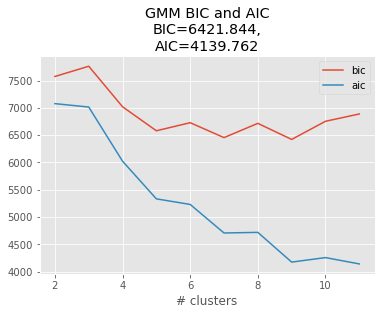

In [26]:
bics, aics = plot_bic_aic(X)

In [27]:
all_dfs = []
for f in [get_sc_pred, get_km_pred, get_gm_pred]:
    dfs = []
    for i in range(y.shape[1]):
        df = pd.DataFrame([get_score(k, f, X, y[:,i]) for k in range(2, no_clusters)],
                          columns=score_columns)
        dfs.append(df)
    all_dfs.append(dfs)

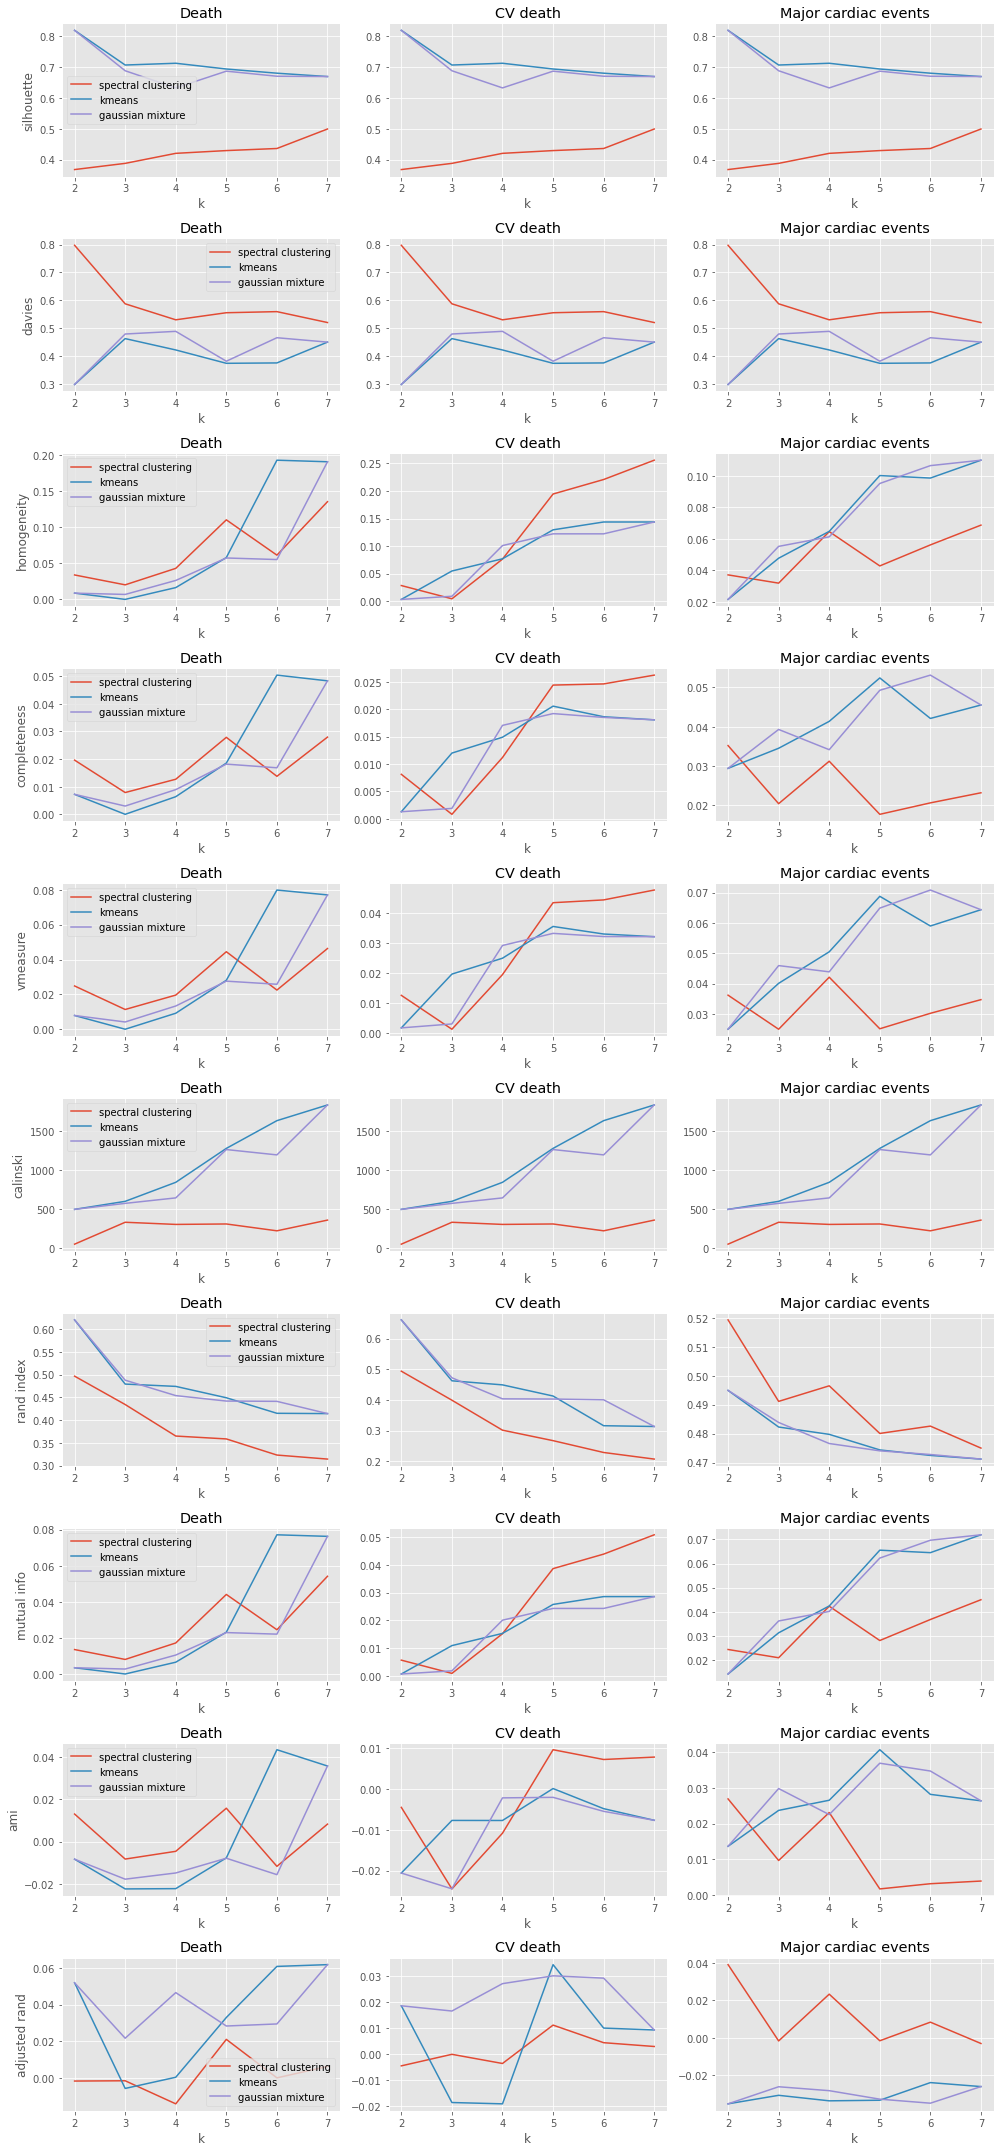

In [28]:
methods = ['spectral clustering', 'kmeans', 'gaussian mixture']

plot_clustering_score(all_dfs, methods, lbl_colname)

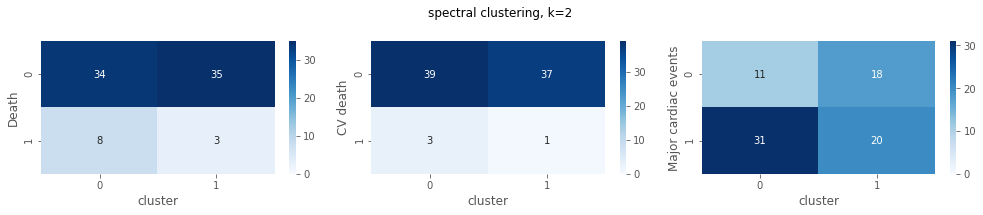

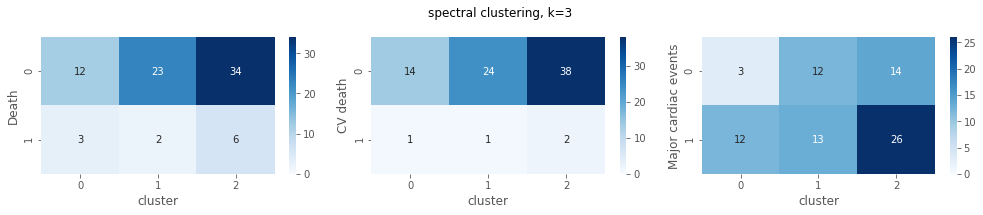

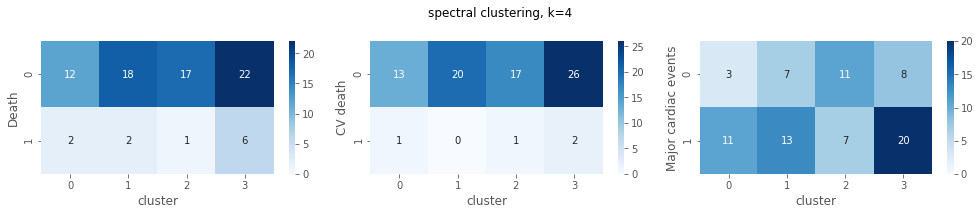

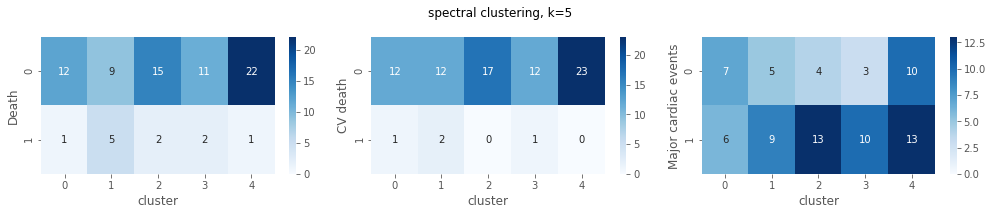

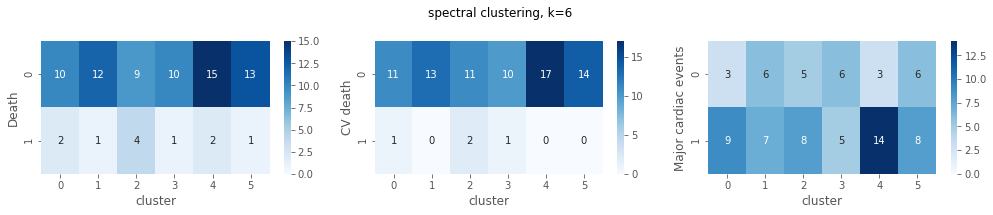

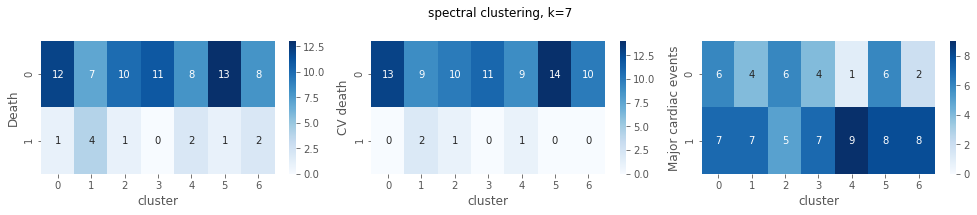

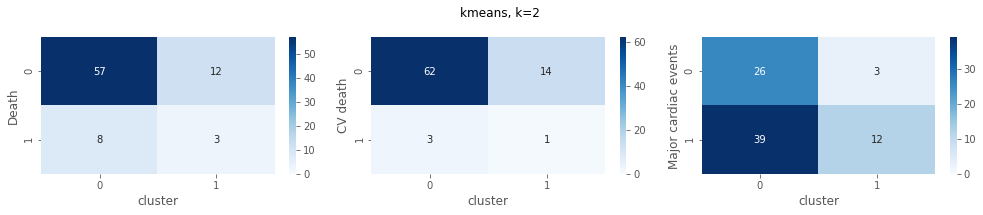

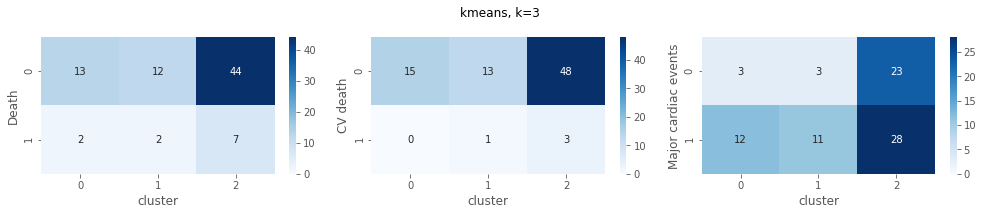

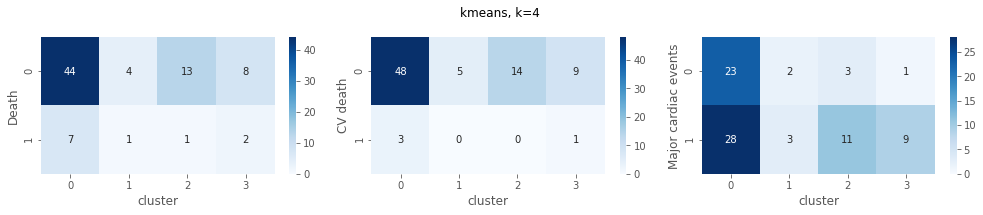

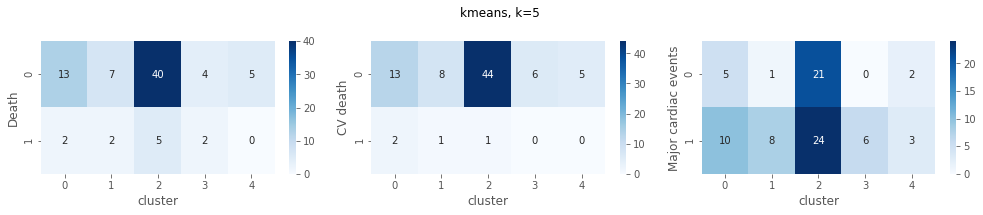

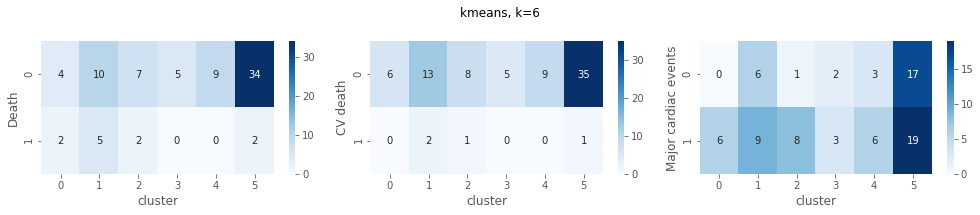

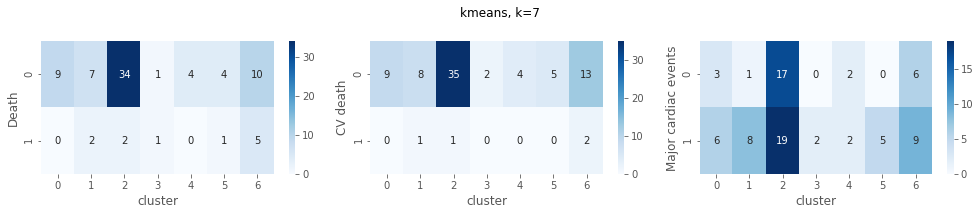

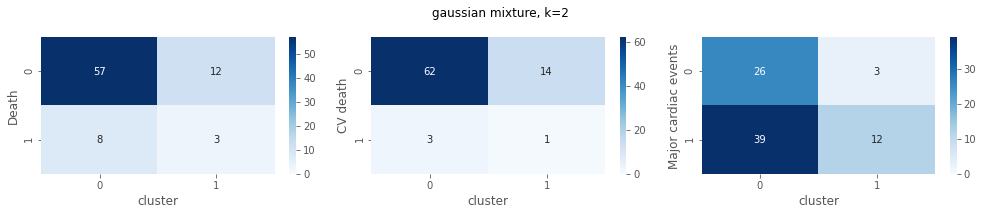

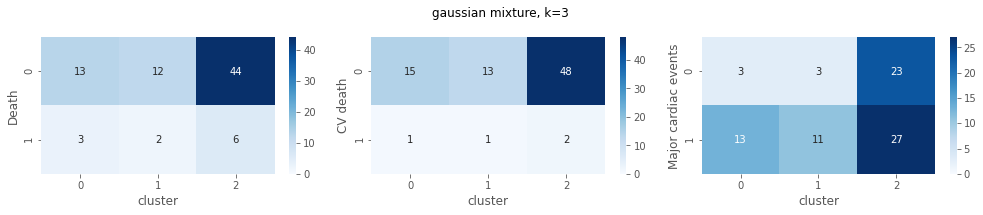

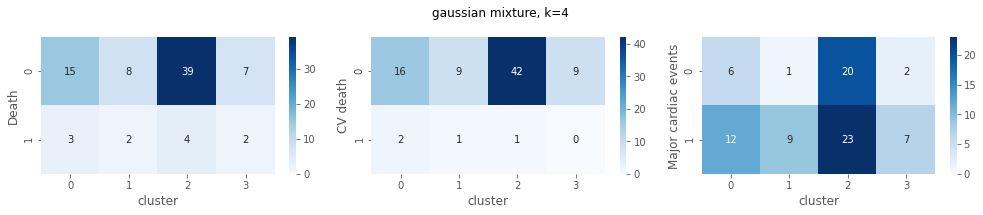

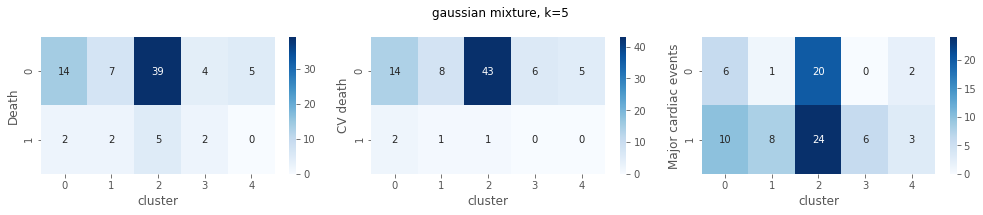

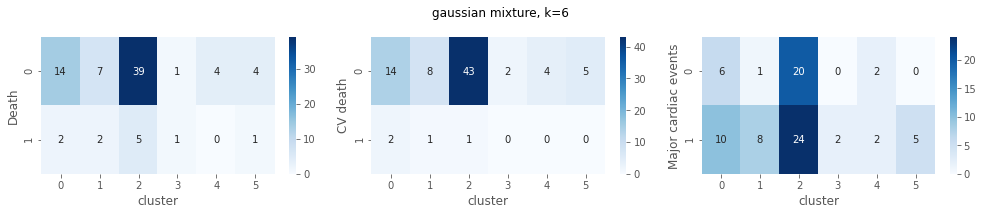

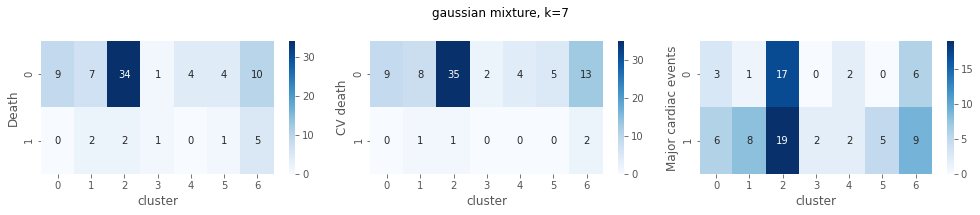

In [29]:
plot_contingency_matrix(all_dfs, methods, lbl_colname)

In [30]:
for i, lbl in enumerate(lbl_colname):
    display(lbl)
    for j, met in enumerate(methods):
        display(met)
        display(all_dfs[j][i])

'Death'

'spectral clustering'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.367360,0.797485,0.033914,0.019626,0.024864,50.988778,0.496519,0.013579,0.012966,-0.001691,"[[34, 35], [8, 3]]","[42, 38]"
1,3,0.387449,0.587329,0.020239,0.007914,0.011379,332.333325,0.434177,0.008104,-0.008285,-0.001540,"[[12, 23, 34], [3, 2, 6]]","[15, 25, 40]"
2,4,0.420017,0.529850,0.043030,0.012719,0.019634,304.688917,0.364873,0.017229,-0.004628,-0.014114,"[[12, 18, 17, 22], [2, 2, 1, 6]]","[14, 20, 18, 28]"
3,5,0.428990,0.555283,0.110192,0.027870,0.044489,310.352085,0.358544,0.044121,0.015716,0.021020,"[[12, 9, 15, 11, 22], [1, 5, 2, 2, 1]]","[13, 14, 17, 13, 23]"
4,6,0.435752,0.559218,0.061331,0.013780,0.022504,222.429217,0.323101,0.024557,-0.011722,0.000052,"[[10, 12, 9, 10, 15, 13], [2, 1, 4, 1, 2, 1]]","[12, 13, 13, 11, 17, 14]"
5,7,0.499052,0.520093,0.135323,0.027950,0.046330,360.076174,0.314241,0.054183,0.008207,0.006274,"[[12, 7, 10, 11, 8, 13, 8], [1, 4, 1, 0, 2, 1,...","[13, 11, 11, 11, 10, 14, 10]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.819390,0.297634,0.008747,0.007257,0.007933,497.871457,0.620253,0.003502,-0.008343,0.051855,"[[57, 12], [8, 3]]","[65, 15]"
1,3,0.706831,0.462367,0.000087,0.000039,0.000054,601.110791,0.479114,0.000035,-0.022376,-0.005720,"[[13, 12, 44], [2, 2, 7]]","[15, 14, 51]"
2,4,0.712561,0.421600,0.016422,0.006414,0.009225,845.524853,0.474051,0.006576,-0.022245,0.000373,"[[44, 4, 13, 8], [7, 1, 1, 2]]","[51, 5, 14, 10]"
3,5,0.693904,0.373658,0.058002,0.018567,0.028129,1281.344414,0.449051,0.023224,-0.007731,0.032949,"[[13, 7, 40, 4, 5], [2, 2, 5, 2, 0]]","[15, 9, 45, 6, 5]"
4,6,0.680301,0.375024,0.192734,0.050361,0.079856,1637.746343,0.414873,0.077171,0.043324,0.060790,"[[4, 10, 7, 5, 9, 34], [2, 5, 2, 0, 0, 2]]","[6, 15, 9, 5, 9, 36]"
5,7,0.669409,0.449743,0.190573,0.048292,0.077058,1839.436616,0.414241,0.076305,0.035627,0.061755,"[[9, 7, 34, 1, 4, 4, 10], [0, 2, 2, 1, 0, 1, 5]]","[9, 9, 36, 2, 4, 5, 15]"


...

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.367360,0.797485,0.037200,0.035208,0.036177,50.988778,0.519304,0.024360,0.026951,0.039230,"[[11, 18], [31, 20]]","[42, 38]"
1,3,0.387449,0.587329,0.031971,0.020447,0.024942,332.333325,0.491139,0.020936,0.009660,-0.001713,"[[3, 12, 14], [12, 13, 26]]","[15, 25, 40]"
2,4,0.420017,0.529850,0.064603,0.031229,0.042105,304.688917,0.496519,0.042305,0.023128,0.023383,"[[3, 7, 11, 8], [11, 13, 7, 20]]","[14, 20, 18, 28]"
3,5,0.428990,0.555283,0.042882,0.017738,0.025096,310.352085,0.480063,0.028081,0.001674,-0.001619,"[[7, 5, 4, 3, 10], [6, 9, 13, 10, 13]]","[13, 14, 17, 13, 23]"
4,6,0.435752,0.559218,0.056189,0.020647,0.030198,222.429217,0.482595,0.036795,0.003134,0.008359,"[[3, 6, 5, 6, 3, 6], [9, 7, 8, 5, 14, 8]]","[12, 13, 13, 11, 17, 14]"
5,7,0.499052,0.520093,0.068714,0.023211,0.034700,360.076174,0.475000,0.044997,0.003883,-0.003086,"[[6, 4, 6, 4, 1, 6, 2], [7, 7, 5, 7, 9, 8, 8]]","[13, 11, 11, 11, 10, 14, 10]"


'kmeans'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.819390,0.297634,0.021678,0.029416,0.024961,497.871457,0.494937,0.014196,0.013650,-0.035472,"[[26, 3], [39, 12]]","[65, 15]"
1,3,0.706831,0.462367,0.047765,0.034528,0.040082,601.110791,0.482278,0.031278,0.023729,-0.030897,"[[3, 3, 23], [12, 11, 28]]","[15, 14, 51]"
2,4,0.712561,0.421600,0.064756,0.041361,0.050480,845.524853,0.479747,0.042405,0.026577,-0.033856,"[[23, 2, 3, 1], [28, 3, 11, 9]]","[51, 5, 14, 10]"
3,5,0.693904,0.373658,0.100093,0.052400,0.068789,1281.344414,0.474367,0.065545,0.040767,-0.033536,"[[5, 1, 21, 0, 2], [10, 8, 24, 6, 3]]","[15, 9, 45, 6, 5]"
4,6,0.680301,0.375024,0.098523,0.042104,0.058996,1637.746343,0.472468,0.064517,0.028229,-0.024072,"[[0, 6, 1, 2, 3, 17], [6, 9, 8, 3, 6, 19]]","[6, 15, 9, 5, 9, 36]"
5,7,0.669409,0.449743,0.109833,0.045519,0.064363,1839.436616,0.471203,0.071923,0.026416,-0.026207,"[[3, 1, 17, 0, 2, 0, 6], [6, 8, 19, 2, 2, 5, 9]]","[9, 9, 36, 2, 4, 5, 15]"


'gaussian mixture'

,k,silhouette,davies,homogeneity,completeness,vmeasure,calinski,rand index,mutual info,ami,adjusted rand,contingency matrix,counts
0,2,0.819390,0.297634,0.021678,0.029416,0.024961,497.871457,0.494937,0.014196,0.013650,-0.035472,"[[26, 3], [39, 12]]","[65, 15]"
1,3,0.688201,0.478861,0.055259,0.039305,0.045936,575.078620,0.483861,0.036186,0.029860,-0.026299,"[[3, 3, 23], [13, 11, 27]]","[16, 14, 50]"
2,4,0.632533,0.488419,0.061301,0.034163,0.043875,645.419270,0.476582,0.040143,0.022548,-0.028403,"[[6, 1, 20, 2], [12, 9, 23, 7]]","[18, 10, 43, 9]"
3,5,0.686887,0.381183,0.095089,0.049261,0.064901,1266.434599,0.474051,0.062268,0.036979,-0.032967,"[[6, 1, 20, 0, 2], [10, 8, 24, 6, 3]]","[16, 9, 44, 6, 5]"
4,6,0.670395,0.465533,0.106399,0.053114,0.070857,1197.882373,0.472785,0.069674,0.034784,-0.035124,"[[6, 1, 20, 0, 2, 0], [10, 8, 24, 2, 2, 5]]","[16, 9, 44, 2, 4, 5]"
5,7,0.669409,0.449743,0.109833,0.045519,0.064363,1839.436616,0.471203,0.071923,0.026416,-0.026207,"[[3, 1, 17, 0, 2, 0, 6], [6, 8, 19, 2, 2, 5, 9]]","[9, 9, 36, 2, 4, 5, 15]"
